
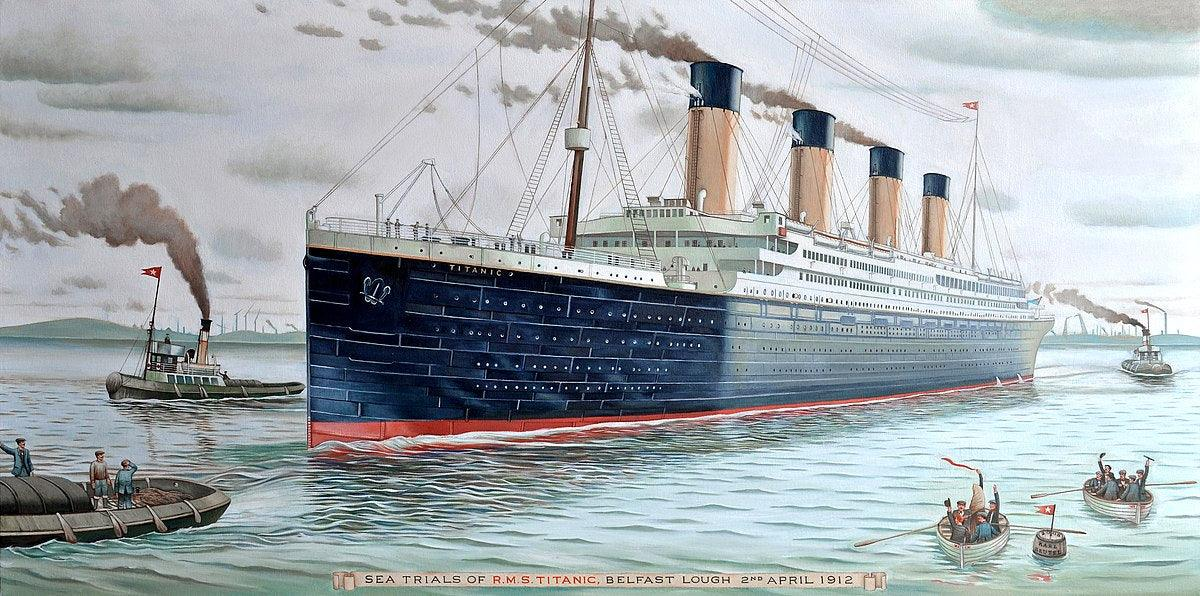

In [ ]:
#@title Project
import requests
from IPython.display import Image, display
from IPython.display import HTML

# Direct image URL
image_url = "https://michaelgabriels.com/cdn/shop/articles/oh-the-jewels-that-were-lost-the-110th-anniversary-of-titanic-sinking-michael-gabriels.jpg?v=1741185340"

# Download the image
response = requests.get(image_url)
with open('image.jpg', 'wb') as file:
    file.write(response.content)

import base64

# Convert the image to a base64 string
with open("image.jpg", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode()

# Create the HTML code with the base64 image
html_code = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Portfolio Header</title>
    <!-- Include Font Awesome -->
    <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.0.0-beta3/css/all.min.css">
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 0;
            padding: 0;
        }}
        .header {{
            display: flex;
            align-items: flex-start; /* Align items to the top */
            /*align-items: center;*/
            padding: 20px;
            background-color: #f4f4f4;
            border-bottom: 2px solid #ccc;
        }}
        .header img {{
            border-radius: 50%;
            width: 100px;
            height: 100px;
            object-fit: cover;
            margin-right: 20px;
            box-shadow: 0 0 20px #86e3dd; /* Glowing effect */
            vertical-align: top;
        }}
        .header .text-container {{
            display: flex;
            flex-direction: column;
        }}
        .header h1 {{
            margin: 0;
            font-size: 2em;
        }}
        .header p {{
            margin: 5px 0 0 0;
            font-size: 1em;
            color: #666;
        }}
        .header .social-icons {{
            margin-top: 10px;
        }}
        .header .social-icons a {{
            margin-right: 10px;
            color: #666;
            text-decoration: none;
            font-size: 1.5em;
        }}
        .header .social-icons a:hover {{
            color: #000;
        }}
    </style>
</head>
<body>
    <header class="header">
        <img src="data:image/jpeg;base64,{encoded_string}" alt="Profile Picture">
        <div class="text-container">


            <h1>Luxury yacht — data analytics project</h1>
            <p>#sql #python #tableau</p>
            &nbsp;
            <p>Victory Nwobia</p>

            <div class="social-icons">

                <a href="https://uk.linkedin.com/in/victorynwobia" target="_blank"><i class="fab fa-linkedin"></i></a>
                <a href="mailto:v.nwobia.25@abdn.ac.uk"><i class="fas fa-envelope"></i>


            </div>
        </div>
    </header>
</body>
</html>
"""

# Display the HTML code in the Jupyter/Colab notebook
display(HTML(html_code))

# Introduction

##Stage 1. Project brief with management

I work for a company that builds luxury yachts and we wants to investigate the Titanic tragedy to improve our designs.

We aim to ensure that in emergencies, all passengers, regardless of class and age, have equal access to emergency exits and equipment.

Our team suspects that higher-class passengers on the Titanic had higher survival chances, and wants you to visualize the data to verify this suspicion.

**Goals:** See if survival rate had anything to do with the passanger class. Also, access the age of the passengers within each classs to indentify vulnerable age categories.



In [ ]:
#@title Step 1. Convert CSV file to an SQL database

import pandas as pd
import gdown

# Csv file ID from the Google Drive link
file_id = '15cFsnPnHc7KlzV0C9QQ5wG5v8PWqJ65C'

download_url = f'https://drive.google.com/uc?id={file_id}'

# Download the file
output_file = 'downloaded_file.csv'
gdown.download(download_url, output_file, quiet=False)

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(output_file)

# Assuming ipython-sql is installed
%load_ext sql

# Use a file-based SQLite database
database_filename = 'my_database.db'
df.to_sql('titanic_data', f'sqlite:///{database_filename}', if_exists='replace', index=False)

# Now connect ipython-sql to the same file-based database
%sql sqlite:///my_database.db

# ATTENTION: After this tutorial was published,
#there was a change behind the SQL functionality used here in Jupyter Notebook.
#We need to add this code to fix it. Without it, the whole thing won't work
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

Downloading...
From: https://drive.google.com/uc?id=15cFsnPnHc7KlzV0C9QQ5wG5v8PWqJ65C
To: /content/downloaded_file.csv
100%|██████████| 61.2k/61.2k [00:00<00:00, 53.8MB/s]


In [ ]:
#@title Step 2. SQL — Query the data
# Query the data to see if it works
project_data = %sql SELECT survived, Pclass, Age FROM titanic_data


 * sqlite:///my_database.db
Done.


Data description
<table>
<tbody>
<tr><th><b>Variable</b></th><th><b>Definition</b></th><th><b>Key</b></th></tr>
<tr>
<td>survival</td>
<td>Survival</td>
<td>0 = No, 1 = Yes</td>
</tr>
<tr>
<td>pclass</td>
<td>Ticket class</td>
<td>1 = 1st, 2 = 2nd, 3 = 3rd</td>
</tr>
<tr>
<td>sex</td>
<td>Sex</td>
<td></td>
</tr>
<tr>
<td>Age</td>
<td>Age in years</td>
<td></td>
</tr>
<tr>
<td>sibsp</td>
<td># of siblings / spouses aboard the Titanic</td>
<td></td>
</tr>
<tr>
<td>parch</td>
<td># of parents / children aboard the Titanic</td>
<td></td>
</tr>
<tr>
<td>ticket</td>
<td>Ticket number</td>
<td></td>
</tr>
<tr>
<td>fare</td>
<td>Passenger fare</td>
<td></td>
</tr>
<tr>
<td>cabin</td>
<td>Cabin number</td>
<td></td>
</tr>
<tr>
<td>embarked</td>
<td>Port of Embarkation</td>
<td>C = Cherbourg, Q = Queenstown, S = Southampton</td>
</tr>
</tbody>
</table>

In [ ]:
#@title Step 3. Python

# Get the data to Python environment

df = pd.DataFrame(project_data)

#Display the first 10 rows of the Dataframe
print(df.head(10))

   Survived  Pclass   Age
0         0       3  22.0
1         1       1  38.0
2         1       3  26.0
3         1       1  35.0
4         0       3  35.0
5         0       3   NaN
6         0       1  54.0
7         0       3   2.0
8         1       3  27.0
9         1       2  14.0


In [ ]:
# Display basic information

print("Basic information")
print(df.info())

# Display summary statistics
print("\n Summary Statistics: ")
print(df.describe())

# Display number of missing values in each column
print("\n Number of missing values: ")
print(df.isnull().sum())

Basic information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

 Summary Statistics: 
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    

In [ ]:
# to clean my data
# We are replacing the missing values with the mean method

age_mean = df['Age'].mean()

# Replace missing values in the Age column with the mean
df['Age'].fillna(age_mean, inplace=True)

# Verify they are no missing values:
print("\n Number of missing values in age column: ")
print(df['Age'].isnull().sum())





 Number of missing values in age column: 
0


/tmp/ipykernel_17138/1054325298.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(age_mean, inplace=True)


In [ ]:
# Round the values in the Age column
df['Age'] = df['Age'].round()

# categorize age group
def categorize_age(age):
  if age <= 14:
    return 'children'
  elif 15 <= age <= 64:
    return "Youth & Adults"
  else:
    return "Seniors"

#Create the "age_category" column
df['age_category'] = df['Age'].apply(categorize_age)

# display full table sample -- df.head(10)
print(df['age_category'].value_counts())

age_category
Youth & Adults    802
children           78
Seniors            11
Name: count, dtype: int64


In [ ]:
# Export the dataframe to an excel file

df.to_excel("output.xlsx", index = False)

print("\n Data has been exported to output.xlsx")
# normally exporting to the cloud would have been the right choice but since i'm working locally i'm exporting it to my machine


 Data has been exported to output.xlsx


In [ ]:
#@title Tableau Dashboard
from IPython.display import HTML

HTML("""
<div class='tableauPlaceholder' id='viz1779126602610' style='position: relative'><noscript><a href='#'><img alt=' ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Ti&#47;Titanic1-DAproject&#47;Titanic1-DAproject-TableauDashboard&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='Titanic1-DAproject&#47;Titanic1-DAproject-TableauDashboard' /><param name='tabs' value='yes' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;Ti&#47;Titanic1-DAproject&#47;Titanic1-DAproject-TableauDashboard&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='en-US' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1779126602610');                    var vizElement = divElement.getElementsByTagName('object')[0];                    if ( divElement.offsetWidth > 800 ) { vizElement.style.minWidth='1024px';vizElement.style.maxWidth='100%';vizElement.style.minHeight='818px';vizElement.style.maxHeight=(divElement.offsetWidth*0.75)+'px';} else if ( divElement.offsetWidth > 500 ) { vizElement.style.minWidth='1024px';vizElement.style.maxWidth='100%';vizElement.style.minHeight='818px';vizElement.style.maxHeight=(divElement.offsetWidth*0.75)+'px';} else { vizElement.style.width='100%';vizElement.style.minHeight='1450px';vizElement.style.maxHeight=(divElement.offsetWidth*1.77)+'px';}                     var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>
""")


[Link Tableau](https://public.tableau.com/views/Titanic1-DAproject/Titanic1-DAproject-TableauDashboard?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)


**Goal**: See if survival rate had anything to do with the passanger class. Also, access the age of the passengers within each classs to indentify vulnerable age categories.

**Assessment**: The data analytics dashboard reveals significant differences in survival rates among various passenger classes on the Titanic. When examining the survival percentages, a substantial disparity is evident. First-class passengers had almost three times the survival rate compared to third-class passengers.

For first-class passengers, the survival rate is approximately 60%. However, when considering the percentage of survivors within each class, the rate is notably higher, emphasizing the critical need to differentiate between overall survival rates and class-specific survival percentages.

Age also played a significant role in survival outcomes. Second-class children had a 100% survival rate, compared to 80% for first-class and 40% for third-class children. No seniors survived in the second and third classes, while only 17% (one individual) survived in the first class. It is essential to conduct a deeper statistical analysis for the first class result to determine if this survival rate among seniors is statistically significant or due to chance.


**Recommendations**:

	•	Focus on minimizing the disparity between passenger classes.
	•	Investigate emergency accessibility measures to improve survival rates for all age categories across all classes.
	•	Use these insights to initiate further data analysis (statistical analysis) to design ships that ensure more equitable safety provisions for all passengers, regardless of class or age.